# 00 — Look at the signal before you analyse it

**Goal of this notebook:** put the actual per-channel signal on screen, with the task's
event triggers drawn on top of it, and browse it — the way you would open `raw.plot()` or
`epochs.plot()` in MNE before touching an analysis.

Everything in notebooks 02–04 is an *average*: PSTHs, tuning curves, decoding accuracy.
Averages are where the science is, but they are also where problems hide. A dead channel, a
saturating artefact, a trigger that lands 200 ms from where you think it does — none of
these announce themselves in a group mean. They just quietly bend the result.

So this notebook is numbered `00`: looking at the raw signal is what you do *first*.

---

## ⚠️ First, an honest word about what "raw" means here

**This dataset contains no raw voltage traces.** There are no 30 kHz waveforms, no LFP, no
spike snippets. By the time the data reached us the pipeline had already:

1. band-pass filtered 250–5000 Hz,
2. detected threshold crossings (and computed spike-band power),
3. **binned** them into 10–20 ms windows,
4. **smoothed** them,
5. dropped channels below 2 Hz.

Steps 3 and 4 are irreversible. So "raw" in this notebook means *the rawest thing the
dataset provides* — the per-channel binned rate time series. We are looking at a heavily
processed derivative of cortical activity, not at cortex. That is worth holding in mind
whenever a trace looks suspiciously smooth: it is smooth because someone smoothed it.

## Why this notebook uses two different files

MNE's `raw.plot` browses a *continuous* recording. The `fig1` files are **trialised**, and
they cannot be turned back into one:

- each epoch spans 2.98 s, from −1000 ms to +1980 ms around target onset,
- but the median trial lasts only 2.34 s, and each epoch starts a full second *before* its
  trial begins.

So consecutive epochs **overlap in real recording time**. Gluing them end to end would
produce a picture in which the x-axis is not time — a display fiction. We do not do that.

Instead we use each file for what it actually is:

| view | file | what it gives you |
|---|---|---|
| **`raw.plot`** | `fig5_{PARTICIPANT}_continuous.h5` | 239 s of genuinely unbroken recording, with real trigger times on the same clock |
| **`epochs.plot`** | `fig1_{PARTICIPANT}_delay.h5` | one trial at a time — the data the decoding actually runs on |
| **`epochs.plot_image`** | `fig1_T16_delay.h5` | every trial for one channel, grouped by direction |

> ### ⚠️ About the continuous file
> `fig5_T16_continuous.h5` is from a **different task** — closed-loop BCI cursor control
> driven by preparatory activity, not the open-loop instructed-delay task — and it is
> **preprocessed differently**: causal exponential smoothing (τ = 28–70 ms) instead of the
> acausal σ = 100 ms Gaussian, z-scored, and with no 2 Hz channel cut.
>
> It is here **to be looked at**. No number from it enters any result in this project.
> Its value is that it is the only place in the dataset where you can watch the signal and
> the task unfold together in real time.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src import plotting
from src.data_loading import load_continuous_data, load_trial_data
from src.preprocessing import direction_labels, pick_feature, select_trials, to_hz

np.random.seed(config.RANDOM_STATE)
plotting.use_house_style()
config.ensure_output_dirs()

# Browsing needs a real window. An inline PNG cannot be zoomed, and this whole
# notebook is about looking closely, so every figure below opens in its own
# resizable window with matplotlib's pan / zoom / save toolbar. The slider cells
# redraw into that same window rather than opening a new one per drag.
#
# Set this to False for inline figures - and do set it to False before re-running
# the notebook to regenerate the PNGs stored in it, because a headless run has no
# screen to put a window on.
FIGURE_WINDOWS = True

# Every knob this notebook has lives here. `participant` is the one entry that
# changes which data is loaded; the rest only decide what you are looking at, so
# the static figures and the slider defaults below cannot drift apart.
BROWSE = dict(
    participant="T11",      # None = whatever config.py selects; or "T5" / "T11" / "T16"
    start_s=20.0,          # continuous browser: where the window opens
    window_s=25.0,         # continuous browser: how much time it shows
    n_channels=18,         # continuous browser: stacked traces
    scale_z=4.0,           # continuous browser: trace spacing, in SD
    sd_threshold=0.01,     # a feature flatter than this counts as dead
    trial_pick=2,          # which go trial the close-up frames
    trial_pad_s=1.0,       # padding either side of that trial
    trial_n_channels=12,   # close-up: stacked traces
    epoch_trial=0,         # fig1 epoch browser: trial index
    epoch_n_channels=18,   # fig1 epoch browser: stacked traces
    epoch_scale_hz=15.0,   # fig1 epoch browser: trace spacing, in Hz
)

# Switching participant here beats editing config.py when you only want to look:
# it rebinds config.PARTICIPANT for this session, so every cell below - and the
# file lookups in config - follow along. None puts config.py back in charge, so
# re-running this cell never leaves a stale override behind. Notebooks 01-04 read
# config.py directly and are not affected by this.
config.select_participant(BROWSE["participant"])

backend = plotting.use_external_windows() if FIGURE_WINDOWS else None
print("ready -", f"figures open in their own window ({backend})" if backend
      else "figures inline")
print(f"participant: {config.PARTICIPANT}"
      + ("" if BROWSE["participant"] is None else "  (overridden here, not in config.py)"))

ready - figures open in their own window (qtagg)
participant: T11  (overridden here, not in config.py)


## 1. A genuinely continuous recording

Load it and look at what is actually there before plotting anything.

In [8]:
# Not every participant has a continuous block: it exists for T11 and T16 only.
# Ask first, so a participant without one skips these sections instead of
# stopping the notebook - the fig1 views in section 7 are independent.
cont_path = config.find_data_file("continuous", figure="fig5")
HAVE_CONTINUOUS = cont_path is not None

if not HAVE_CONTINUOUS:
    have = config.available_participants("continuous", figure="fig5")
    print(f"No fig5_{config.PARTICIPANT}_continuous.h5 - sections 1 to 6 are skipped.")
    print(f"A continuous block exists for: {', '.join(have)}.")
    print("Sections 7 and 8 (the fig1 epoch views) are independent and run below.")
else:
    cont = load_continuous_data(config.PARTICIPANT, config.candidate_data_dirs())
    print(cont)
    print()
    print(f"duration        : {cont.duration_s:.1f} s of unbroken {cont.bin_s * 1000:.0f} ms bins")
    print(f"features        : {cont.n_features}  (all spike + spike-band-power channels)")
    print(f"keep_chans      : {cont.keep_chans.size}  (the subset the online decoder used)")
    print(f"units           : z-scored arbitrary units, causal exponential smoothing")

    trials = cont.trials
    n_trials = trials["start_time"].size
    n_nogo = int(np.nansum(trials["no_go_bool"]))
    print(f"\ntrials          : {n_trials}  ({n_nogo} no-go, {n_trials - n_nogo} go)")
    print(f"go_cue_time NaN : {int(np.isnan(trials['go_cue_time']).sum())}  "
          f"(NaN exactly on the no-go trials - there was no go cue)")

    gaps = (trials["start_time"][1:] - trials["end_time"][:-1]) / 1000
    print(f"\ntrial duration  : median {np.median((trials['end_time'] - trials['start_time']) / 1000):.2f} s")
    print(f"inter-trial gap : median {np.median(gaps):.2f} s   <- real dead time, "
          f"which the trialised fig1 files hide completely")


ContinuousData(T11: 21763 bins x 384 features, bin=10 ms, 217.6 s, 93 trials)

duration        : 217.6 s of unbroken 10 ms bins
features        : 384  (all spike + spike-band-power channels)
keep_chans      : 93  (the subset the online decoder used)
units           : z-scored arbitrary units, causal exponential smoothing

trials          : 93  (0 no-go, 93 go)
go_cue_time NaN : 0  (NaN exactly on the no-go trials - there was no go cue)

trial duration  : median 1.57 s
inter-trial gap : median 0.61 s   <- real dead time, which the trialised fig1 files hide completely


c:\Users\gilad\Intracortical_project\intracortical-prep-decoding\src\data_loading.py:339: UserWarning: fig5_T11_continuous.h5: clock steps vary (10-11 ms); using the median, 10 ms. This stream is for viewing only, and its time axis is plotted from the recorded clock, so the jitter is visible rather than smoothed over.
  bin_s = _derive_bin_size(clock_ms, path, strict=False)


That last line is the first thing the continuous view buys us. In `fig1` every epoch begins
at −1000 ms and the recording appears to run continuously from trial to trial. In reality
there are ~2 s of dead time between trials where nothing task-related happens at all.

## 2. Building the browser inputs

Three things go into the browser: the **signals**, the **event triggers**, and the
**auxiliary channels** (MNE would call these misc/stim rows).

The event times in `trial_info` are on the same clock as `clock_time`, so no alignment
guesswork is needed — we just subtract the recording start so the axis begins at 0 s.

In [9]:
if not HAVE_CONTINUOUS:
    print("skipped - no continuous block for this participant")
else:
    t_s = (cont.clock_ms - cont.clock_ms[0]) / 1000.0      # seconds from recording start

    def to_seconds(ms):
        return (np.asarray(ms, dtype=float) - cont.clock_ms[0]) / 1000.0

    events = {
        "trial start": to_seconds(trials["start_time"]),
        "go cue":      to_seconds(trials["go_cue_time"]),   # NaN on no-go: skipped automatically
        "trial end":   to_seconds(trials["end_time"]),
    }

    # Auxiliary rows: what the participant and the online decoder were doing.
    # Which rows exist depends on the participant - EMG was recorded for T16 only -
    # so each is added only if the file actually carries it.
    aux = {}
    if cont.cursor is not None:
        aux["cursor X"] = cont.cursor[:, 0]
        aux["cursor Y"] = cont.cursor[:, 1]
    if cont.emg is not None:
        aux["EMG 1"] = cont.emg[:, 0]
    if cont.cursor is not None:
        aux["cursor speed"] = (np.r_[0.0, np.linalg.norm(np.diff(cont.cursor, axis=0), axis=1)]
                               / cont.bin_s)
    if cont.dec_move_state is not None:
        aux["decoder move-state"] = cont.dec_move_state

    for name, times in events.items():
        finite = np.isfinite(times).sum()
        print(f"{name:12s}: {finite} events")
    print(f"\naux rows: {list(aux)}")


trial start : 93 events
go cue      : 93 events
trial end   : 93 events

aux rows: ['cursor X', 'cursor Y', 'cursor speed', 'decoder move-state']


## 3. Dead channels — the reason `keep_chans` exists

Before browsing, one check that only ever happens if you look: **how many of the recorded
features are flat lines?**

In [10]:
if not HAVE_CONTINUOUS:
    print("skipped - no continuous block for this participant")
else:
    sd_threshold = BROWSE["sd_threshold"]
    sds = cont.neural.std(axis=0)
    dead = cont.dead_features(sd_threshold=sd_threshold)

    print(f"features with SD < {sd_threshold} (flat)  : {dead.size} / {cont.n_features}")
    print(f"features that vary              : {cont.n_features - dead.size}")
    print(f"of the {cont.keep_chans.size} keep_chans, how many are flat? "
          f"{int(np.isin(cont.keep_chans, dead).sum())}")

    fig, ax = plt.subplots(figsize=(9, 3.0))
    ax.plot(sds, color=plotting.TRACE_COLOR, lw=0.8)
    ax.scatter(cont.keep_chans, sds[cont.keep_chans], s=12, color=plotting.ACCENT,
               zorder=4, label=f"keep_chans (n={cont.keep_chans.size})")
    ax.axhline(sd_threshold, color=plotting.INK_MUTED, ls=(0, (4, 3)), lw=1.0)
    ax.annotate(f"SD = {sd_threshold}", xy=(1.0, sd_threshold),
                xycoords=("axes fraction", "data"),
                xytext=(-4, 4), textcoords="offset points", fontsize=8,
                color=plotting.INK_MUTED, ha="right", va="bottom")
    half = cont.n_features // 2
    ax.set_xlabel(f"feature index (0-{half - 1} threshold crossings, "
                  f"{half}-{cont.n_features - 1} spike-band power)")
    ax.set_ylabel("SD over the block")
    ax.set_title("Which features carry any signal at all?")
    ax.legend(loc="upper left")
    fig.tight_layout()
    fig.savefig(config.FIGURES_DIR / "continuous_channel_sd.png", bbox_inches="tight")
    plotting.show(fig, "channel SD")


features with SD < 0.01 (flat)  : 28 / 384
features that vary              : 356
of the 93 keep_chans, how many are flat? 0


**More than half the features are flat**, and *every single* `keep_chans` feature is live.
That is not a coincidence — it is what `keep_chans` is for, and this plot is the evidence.

Electrodes fail, or sit in white matter, or never had a neuron near them. The array has
physical channels that were simply never useful. If you fed all 512 features to a decoder,
the flat ones would contribute nothing but would still be standardised — dividing a
constant by a near-zero standard deviation, which is exactly how you manufacture numerical
garbage. Notebooks 02–04 use `fig1`, which already had this cut applied for us; here we can
see what was cut.

So the browser defaults to the live subset.

In [11]:
if not HAVE_CONTINUOUS:
    print("skipped - no continuous block for this participant")
else:
    live = cont.keep_chans[~np.isin(cont.keep_chans, dead)]
    signals = cont.neural[:, live]
    labels = [f"f{int(c)}" for c in live]
    print(f"browsing {signals.shape[1]} live features")


browsing 93 live features


## 4. The raw browser

This is the `raw.plot` equivalent: channels stacked top to bottom, time along the x-axis,
event triggers as vertical rules, and the behavioural channels in a panel below.

Traces are drawn in a single neutral colour on purpose. With twenty overlapping series a
categorical palette encodes nothing — the y-position already identifies the channel — and
would only add noise. Colour is reserved for the three event types, which are also
distinguished by line style so they remain separable in greyscale or for a colour-blind
reader.

The `scale` argument is MNE's `scalings`: the vertical spacing between channels, in signal
units. The default separates the median channel; raise it if traces collide, lower it to
fit more channels on screen.

In [12]:
if not HAVE_CONTINUOUS:
    print("skipped - no continuous block for this participant")
else:
    fig = plotting.plot_signal_browser(
        t_s, signals, labels,
        events=events, aux=aux,
        start_s=BROWSE["start_s"], duration_s=BROWSE["window_s"],
        n_channels=BROWSE["n_channels"],
        units="z",
        title=f"{config.PARTICIPANT} continuous block - {BROWSE['n_channels']} of "
              f"{signals.shape[1]} live features",
    )
    fig.savefig(config.FIGURES_DIR / "raw_browser_continuous.png", bbox_inches="tight")
    plotting.show(fig, "continuous browser")


**What to look for, in order:**

1. **Do the triggers land where the signal changes?** The go cue (orange dashed) should be
   followed — not preceded — by EMG activity and then cursor motion. If a trigger sat in the
   middle of a movement, or after it, the alignment would be wrong and every result built
   on it would be wrong too.
2. **Trials without a go cue.** Some trials show a start and an end with no orange line
   between them. Those are the no-go catch trials (the count is printed in section 1), and the
   cursor stays put through them.
3. **Do any channels look pathological?** Flat stretches, sudden steps, one channel
   dominating everything, traces clipping at a ceiling.
4. **Is there drift?** A slow wander across the whole block, unrelated to the task, is the
   block-specific drift that motivates grouping cross-validation folds by block in
   notebook 03.

## 5. Browse it interactively

Now the same figure with sliders. Drag the time slider to scan the whole block, change how
many channels are shown, and adjust the vertical scale.

> **Note:** the sliders are drawn *on the figure*, in the same window, so they travel with
> it and work in any frontend. They do need a live kernel and a GUI backend: under
> `FIGURE_WINDOWS = False`, or in a headless run, the cell draws a single static figure at
> the starting values instead - which is what the saved notebook stores.

In [13]:
if not HAVE_CONTINUOUS:
    print("skipped - no continuous block for this participant")
else:
    def draw_continuous(fig, top, start_s, duration_s, n_channels, scale):
        plotting.plot_signal_browser(
            t_s, signals, labels, events=events, aux=aux,
            start_s=start_s, duration_s=duration_s,
            n_channels=n_channels, scale=scale, units="z",
            title=f"{config.PARTICIPANT} continuous - {start_s:.0f} to "
                  f"{start_s + duration_s:.0f} s",
            fig=fig, top=top,
        )

    # Keep the figure in a name: the slider callbacks are only reachable through it.
    continuous_browser = plotting.browse(
        draw_continuous, name="continuous browser", figsize=(12, 8.5),
        start_s=plotting.slider("start (s)", 0.0, max(0.0, float(t_s[-1]) - 5),
                                value=BROWSE["start_s"], step=1.0),
        duration_s=plotting.slider("window (s)", 5.0, 60.0,
                                   value=BROWSE["window_s"], step=5.0),
        n_channels=plotting.slider("channels", 4, 40,
                                   value=BROWSE["n_channels"], step=2),
        scale=plotting.slider("scale (z)", 1.0, 15.0,
                              value=BROWSE["scale_z"], step=0.5),
    )


## 6. One trial, close up

Zooming to a single trial makes the sequence explicit: go cue → muscle activity → cursor
movement. This is the ordering that has to hold for the task to make sense, and here you
can confirm it by eye rather than assuming it.

In [8]:
if not HAVE_CONTINUOUS:
    print("skipped - no continuous block for this participant")
else:
    # Take one go trial (those with a finite go cue) and frame it with a little padding.
    go_trials = np.where(np.isfinite(trials["go_cue_time"]))[0]
    tr = int(go_trials[BROWSE["trial_pick"]])
    pad = BROWSE["trial_pad_s"]
    t0 = float(to_seconds(trials["start_time"][tr])) - pad
    t1 = float(to_seconds(trials["end_time"][tr])) + pad

    print(f"trial {tr}: start {to_seconds(trials['start_time'][tr]):.2f}s, "
          f"go cue {to_seconds(trials['go_cue_time'][tr]):.2f}s, "
          f"end {to_seconds(trials['end_time'][tr]):.2f}s, "
          f"delay {trials['delay_data'][tr] / 1000:.2f}s")

    fig = plotting.plot_signal_browser(
        t_s, signals, labels, events=events, aux=aux,
        start_s=t0, duration_s=t1 - t0,
        n_channels=BROWSE["trial_n_channels"], units="z",
        title=f"A single go trial (trial {tr}) - go cue, then EMG, then cursor",
    )
    fig.savefig(config.FIGURES_DIR / "raw_browser_single_trial.png", bbox_inches="tight")
    plotting.show(fig, "single trial")


skipped - no continuous block for this participant


## 7. Back to `fig1`: the epoch view

Now the file the analysis actually uses. Same stacked layout, but one trial at a time,
aligned to target onset at `t = 0`, and in **Hz** rather than z-scores.

Apply the standard trial selection first, so we are browsing exactly the trials the decoder
sees in notebook 03.

In [14]:
td = load_trial_data(config.PARTICIPANT, config.ALIGNMENT, config.FIGURE,
                     config.candidate_data_dirs())
features = pick_feature(td, config.FEATURE_TYPE)
keep, report = select_trials(features, td.delay, td.no_go,
                             config.MIN_DELAY_S, config.GO_TRIALS_ONLY)
print(report)

labels_all, centres = direction_labels(td.target, td.start, config.N_DIRECTIONS)

X_hz = to_hz(features[keep], td.bin_s)          # (trials, bins, channels) in Hz
y = labels_all[keep]
delays_ms = td.delay[keep] * 1000
cursor = td.cursor[keep]
emg = td.optional["emg_data_all"][keep] if "emg_data_all" in td.optional else None
ch_labels = [f"ch{int(c)}" for c in td.keep_chans]
go_cue_times_ms = sorted(np.unique(delays_ms).tolist())
print(f"\nbrowsing {X_hz.shape[0]} trials x {X_hz.shape[2]} channels, in Hz")

Trial selection
  starting trials              : 266
  dropped, non-finite features : 0
  dropped, non-finite delay    : 0
  dropped, delay < 0.8 s        : 0
  dropped, no-go trials        : 92
  --> kept                     : 174

browsing 174 trials x 58 channels, in Hz


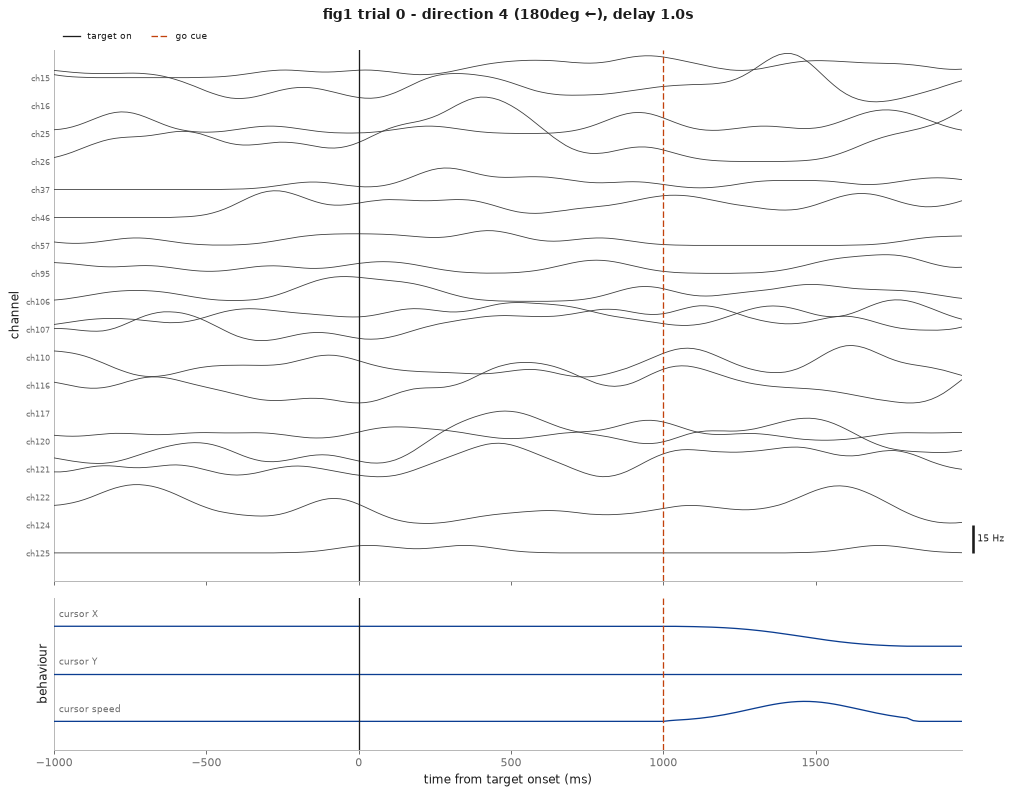

In [15]:
def epoch_aux(trial):
    speed = np.r_[0.0, np.linalg.norm(np.diff(cursor[trial], axis=0), axis=1)] / td.bin_s
    rows = {"cursor X": cursor[trial][:, 0], "cursor Y": cursor[trial][:, 1]}
    if emg is not None:
        rows["EMG 1"] = emg[trial][:, 0]
    rows["cursor speed"] = speed
    return rows

def browse_epoch(trial=BROWSE["epoch_trial"], n_channels=BROWSE["epoch_n_channels"],
                 scale=BROWSE["epoch_scale_hz"], fig=None, top=1.0):
    d = int(y[trial])
    return plotting.plot_epoch_browser(
        td.t_ms, X_hz[trial], ch_labels,
        events={"target on": [0.0], "go cue": [delays_ms[trial]]},
        aux=epoch_aux(trial), n_channels=n_channels, scale=scale, units="Hz",
        title=f"{config.FIGURE} trial {trial} - direction {d} "
              f"({np.degrees(centres[d]):.0f}deg {plotting.DIRECTION_ARROWS[d]}), "
              f"delay {delays_ms[trial] / 1000:.1f}s",
        fig=fig, top=top,
    )

fig = browse_epoch(trial=BROWSE["epoch_trial"])
fig.savefig(config.FIGURES_DIR / "epoch_browser_trial.png", bbox_inches="tight")
plotting.show(fig, "epoch browser")


> ### The acausal smoothing, visible by eye
>
> Compare these traces with the continuous ones in section 4. The `fig1` traces are
> *dramatically* smoother — they look like gentle waves rather than the spiky activity in
> the fig5 block.
>
> That difference is not physiology. It is the **acausal σ = 100 ms Gaussian kernel**
> applied to the `fig1–4` files (fig5 got causal exponential smoothing instead). Each point
> here is a weighted average over roughly ±200 ms of activity — including the future.
>
> Seeing it is the point. This is why notebook 03 refuses to claim an onset latency: on a
> trace this smooth, "when did it start rising" is a question about the kernel as much as
> about cortex.

Now browse trial by trial.

In [16]:
def draw_epoch(fig, top, trial, n_channels, scale):
    browse_epoch(trial=trial, n_channels=n_channels, scale=scale, fig=fig, top=top)


epoch_browser = plotting.browse(
    draw_epoch, name="epoch browser", figsize=(12, 8.5),
    trial=plotting.slider("trial", 0, int(X_hz.shape[0]) - 1,
                          value=BROWSE["epoch_trial"], step=1),
    n_channels=plotting.slider("channels", 4, 40,
                               value=BROWSE["epoch_n_channels"], step=2),
    scale=plotting.slider("scale (Hz)", 5.0, 60.0,
                          value=BROWSE["epoch_scale_hz"], step=5.0),
)


## 8. Every trial at once: `epochs.plot_image`

A single trial is too noisy to show tuning, and a PSTH averages the trials away. The
erpimage sits between them: **one channel, every trial as a row, colour = firing rate**,
with trials grouped by intended direction.

This is where single-trial structure becomes visible. If a channel is genuinely
direction-tuned, one or two of the eight coloured blocks should visibly brighten after
target onset while the others do not — and you can see how *consistent* that is across
individual trials, which no average will ever tell you.

We pick the channel using notebook 02's saved tuning table, so the choice is by a
pre-registered criterion rather than by eye.

In [17]:
# channel_tuning.csv carries no participant tag in its filename, so a table left
# behind by a different participant would rank electrodes this file does not have.
# Notebook 02 writes exactly one row per keep_chans, so the set of ranked
# electrodes must match this participant's exactly; anything else is a foreign
# table. Partial overlap is the dangerous case - array ids are reused across
# participants, so a handful collide by coincidence and would otherwise be
# accepted silently.
tuning_path = config.TABLES_DIR / "channel_tuning.csv"
keep_set = td.keep_chans.astype(int)
tuning = None

if not tuning_path.exists():
    print("NOTE: run notebook 02 first to rank channels by tuning; "
          "using file order instead.")
else:
    table = pd.read_csv(tuning_path).sort_values("F_preparatory", ascending=False)
    ranked = table["electrode"].astype(int)
    if set(ranked) == set(keep_set.tolist()):
        tuning = table
        print(f"channel ranking loaded from {tuning_path.name} "
              f"({len(tuning)} electrodes)")
    else:
        overlap = len(set(ranked) & set(keep_set.tolist()))
        print(f"NOTE: {tuning_path.name} ranks {len(ranked)} electrodes but "
              f"{config.PARTICIPANT} has {keep_set.size} ({overlap} in common) - "
              f"that table was produced for a different participant.")
        print("      Re-run notebook 02 under this participant. Using file order instead.")

ranked_electrodes = keep_set if tuning is None else tuning["electrode"].to_numpy()

def electrode_to_column(electrode):
    return int(np.where(keep_set == int(electrode))[0][0])

best = int(ranked_electrodes[0])
if tuning is None:
    print(f"first electrode in file order: {best}  (no tuning ranking available)")
else:
    print(f"most direction-tuned electrode: {best}  "
          f"(ANOVA F = {float(tuning.iloc[0]['F_preparatory']):.1f})")


NOTE: channel_tuning.csv ranks 61 electrodes but T11 has 58 (9 in common) - that table was produced for a different participant.
      Re-run notebook 02 under this participant. Using file order instead.
first electrode in file order: 15  (no tuning ranking available)


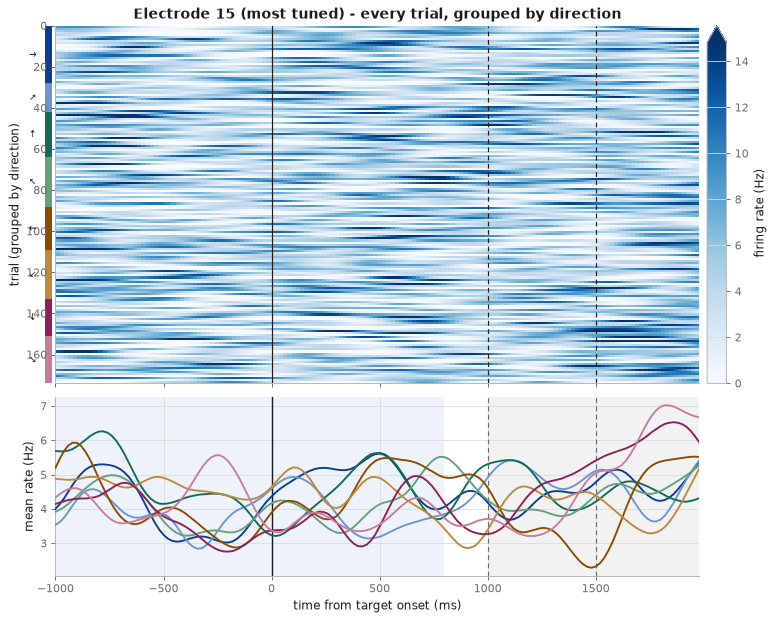

In [18]:
fig = plotting.plot_epochs_image(
    td.t_ms, X_hz[:, :, electrode_to_column(best)], y, centres,
    go_cue_times_ms=go_cue_times_ms,
    prep_window_ms=config.PREP_WINDOW_MS,
    title=f"Electrode {best} (most tuned) - every trial, grouped by direction",
)
fig.savefig(config.FIGURES_DIR / "epochs_image_channel.png", bbox_inches="tight")
plotting.show(fig, "erpimage (tuned)")

### The control: do the same thing for an untuned channel

A picture that looks structured is only meaningful if the same picture looks unstructured
when there is nothing there. Compare the most-tuned channel above with the least-tuned one.

In [14]:
worst = int(ranked_electrodes[-1])
if tuning is None:
    print(f"last electrode in file order: {worst}  (no tuning ranking available)")
    worst_label = f"Electrode {worst}"
else:
    print(f"least direction-tuned electrode: {worst}  "
          f"(ANOVA F = {float(tuning.iloc[-1]['F_preparatory']):.1f})")
    worst_label = f"Electrode {worst} (least tuned)"

fig = plotting.plot_epochs_image(
    td.t_ms, X_hz[:, :, electrode_to_column(worst)], y, centres,
    go_cue_times_ms=go_cue_times_ms,
    prep_window_ms=config.PREP_WINDOW_MS,
    title=f"{worst_label} - the same plot with no tuning to see",
)
fig.savefig(config.FIGURES_DIR / "epochs_image_untuned.png", bbox_inches="tight")
plotting.show(fig, "erpimage (untuned)")


last electrode in file order: 191  (no tuning ranking available)


<Figure size 990x792 with 3 Axes>

In [15]:
def draw_erpimage(fig, top, rank):
    electrode = int(ranked_electrodes[rank])
    plotting.plot_epochs_image(
        td.t_ms, X_hz[:, :, electrode_to_column(electrode)], y, centres,
        go_cue_times_ms=go_cue_times_ms,
        prep_window_ms=config.PREP_WINDOW_MS,
        title=f"Electrode {electrode} - rank {rank + 1} of "
              f"{len(ranked_electrodes)} by preparatory tuning",
        fig=fig, top=top,
    )


erpimage_browser = plotting.browse(
    draw_erpimage, name="erpimage browser", figsize=(9.5, 7.8),
    rank=plotting.slider("tuning rank", 0, len(ranked_electrodes) - 1,
                         value=0, step=1),
)

## What this view is for

A checklist of things that only ever turn up by looking, each of which would corrupt a
result silently:

| what you might see | what it would mean |
|---|---|
| flat channels | dead electrodes — must be excluded, or standardisation divides by ~0 |
| a trigger inside or after the movement | broken alignment; every time-resolved result invalid |
| one channel dwarfing the rest | an artefact that will dominate a decoder that has not been standardised |
| slow wander across the block | block-specific drift — the reason folds are grouped by block in notebook 03 |
| traces far smoother than physiology allows | smoothing already applied; no onset-latency claims |
| cursor moving before the go cue | anticipation, or a mislabelled trial |

Nothing in this notebook produces a number that appears in a result. That is the point: it
is the step that tells you whether the numbers in notebooks 02–04 are worth computing.

---

## Now try this

1. **Find the worst channel.** In section 3, sort the live features by SD and browse the
   few with the largest values. Is the biggest-amplitude channel carrying signal, or an
   artefact? Would it dominate a decoder if the features were not standardised?
2. **Does EMG lead or lag the cursor?** Zoom into a single go trial in section 6 and read
   the order of go cue, EMG onset, cursor motion. Roughly how long is each gap, and does
   that match a plausible reaction time?
3. **Browse a no-go trial.** Find one where `no_go_bool == 1` and confirm
   nothing happens after the delay would have ended. Does the *neural* signal look
   different from a go trial in that same window?
4. **Compare the smoothing directly.** Put a fig5 trace and a fig1 trace on the same time
   scale. How much detail did the σ = 100 ms acausal kernel remove — and what would that do
   to an attempt to measure when a channel first responded?
5. **Break the alignment on purpose.** In section 7, pass
   `events={"go cue": [delays_ms[trial] - 400]}` and look at the figure. If you had never
   checked the alignment against the cursor, would you have noticed?